<a href="https://colab.research.google.com/github/sli12347-bit/sli12347-bit.github.io/blob/main/Notoebooks/hypothesis_test_1_simone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race,parental_level_of_education,lunch_plan,test_prep_status,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
# Make column names into one string
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Rename some columns with a better description
df = df.rename(columns = {
    "race/ethnicity": "race",
    "lunch": "lunch_plan",
    "test_preparation_course": "test_prep_status"
})
df.head()

,gender,race,parental_level_of_education,lunch_plan,test_prep_status,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
# Checking for any missing values. None, so we are good!
df.isnull().sum()

,0
gender,0
race,0
parental_level_of_education,0
lunch_plan,0
test_prep_status,0
math_score,0
reading_score,0
writing_score,0


In [8]:
# Check column data types
df.dtypes

,0
gender,object
race,object
parental_level_of_education,object
lunch_plan,object
test_prep_status,object
math_score,int64
reading_score,int64
writing_score,int64


In [9]:
# The scores are good already since they are integers. We need to make the first five columns into categorical data types, though.
categorical_columns = [
    "gender", "race", "parental_level_of_education",
    "lunch_plan", "test_prep_status"
]

for col in categorical_columns:
    df[col] = df[col].astype("category")

df.dtypes

,0
gender,category
race,category
parental_level_of_education,category
lunch_plan,category
test_prep_status,category
math_score,int64
reading_score,int64
writing_score,int64


In [27]:
# Statistical testing: ANOVA on the average math scores between racial groups
# Null Hypothesis (Ho): The mean math score is the same across all race/ethnicity groups.
# Alternative Hypothesis (Ha): At least one race/ethnicity group has a different mean math score.

import pandas as pd
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt


groups = [group["math_score"].values for name, group in df.groupby("race")]
f_stat, p_value = f_oneway(*groups)

print("ANOVA (scipy)")
print("F-statistic:", f_stat)
print("p-value:", p_value)




ANOVA (scipy)
F-statistic: 14.593885166332635
p-value: 1.3732194030370688e-11


/tmp/ipykernel_30375/2569796037.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group["math_score"].values for name, group in df.groupby("race")]


A one-way ANOVA was conducted to compare math scores across racial groups. A Tukey HSD post-hoc test was performed to identify which exact group differed.

In [23]:
tukey = pairwise_tukeyhsd(
    endog=df["math_score"],
    groups=df["race"],
    alpha=0.05
)

print("\nTukey HSD Results:")
print(tukey)


Tukey HSD Results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
group A group B   1.8234 0.8724   -3.36  7.0068  False
group A group C   2.8347 0.4968 -2.0028  7.6723  False
group A group D   5.7334 0.0138  0.7824 10.6844   True
group A group E  12.1922    0.0  6.7215 17.6629   True
group B group C   1.0113 0.9452 -2.6867  4.7094  False
group B group D     3.91  0.044  0.0647  7.7552   True
group B group E  10.3688    0.0  5.8741 14.8635   True
group C group D   2.8986  0.129 -0.4659  6.2632  False
group C group E   9.3575    0.0  5.2665 13.4485   True
group D group E   6.4588 0.0003  2.2343 10.6834   True
------------------------------------------------------


The initial ANOVA showed a significant influence of race/ethnicity on math scores (F = 14.59 , p-value = 1.37 x 10^-11). Post-hoc analysis shows that there's a statistically significant difference between groups A&D, A&E, B&D, B&E, C&E, and D&E. The other pairings fail to reject the null hypothesis that there is no difference in means amongst math scores.

<Figure size 640x480 with 0 Axes>

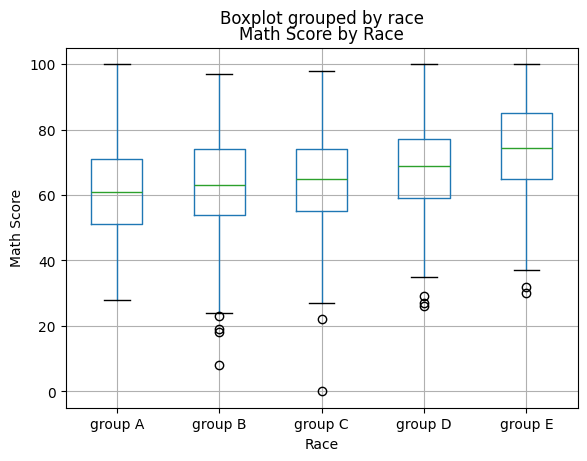

In [24]:
plt.figure()
df.boxplot(column="math_score", by="race")
plt.title("Math Score by Race")
plt.xlabel("Race")
plt.ylabel("Math Score")
plt.show()

This box plot suggests that math performance varies significantly across racial/ethnic groups.